<a href="https://colab.research.google.com/github/adanielce/IA_S8/blob/main/REPORTE_YOLO.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install split-folders pillow ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 48.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 23.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 39.9 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.13
    Uninstalling idna-3.13:
      Successfully uninstalled idna-3.13


In [ ]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import files
from roboflow import Roboflow
from ultralytics import YOLO

# Descarga del dataset desde Roboflow
rf = Roboflow(api_key="KXJIhgvJ3Go3n3m9D1q0")
proyecto = rf.workspace("daniel-ce").project("my-first-project-v9edg")
version = proyecto.version(1)
conjunto_de_datos = version.download("yolov8")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to My-First-Project-1 in yolov8:: 100%|██████████| 1563/1563 [00:00<00:00, 8160.87it/s]


In [ ]:
from ultralytics import YOLO

# Cargar un modelo preentrenado de YOLOv8
model = YOLO('yolov8n.pt')

# Entrenamiento
model.train(
    data='/content/My-First-Project-1/data.yaml',
    name='my_yolov8_model',
    project='YOLOv8_Training', # Carpeta donde se guardarán los resultados

    # Hiperparámetros
    epochs=50,
    batch=64,
    imgsz=640
)

Ultralytics 8.4.54 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=64, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/My-First-Project-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=my_yolov8_model, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=T

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7cc298801be0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
from ultralytics import YOLO

# 1. Cargar el modelo con la ruta exacta de tu captura de pantalla
ruta_pesos = '/content/runs/detect/YOLOv8_Training/my_yolov8_model/weights/best.pt'
modelo_entrenado = YOLO(ruta_pesos)

# 2. Realizar inferencia (predicción) en una imagen de prueba
ruta_imagen_prueba = "/content/My-First-Project-1/valid/images/73_jpg.rf.db418d90593b6854e2431fbd076f3e1a.jpg"

resultados = modelo_entrenado.predict(source=ruta_imagen_prueba, save=True)


image 1/1 /content/My-First-Project-1/valid/images/73_jpg.rf.db418d90593b6854e2431fbd076f3e1a.jpg: 640x640 1 0, 9.1ms
Speed: 3.1ms preprocess, 9.1ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict


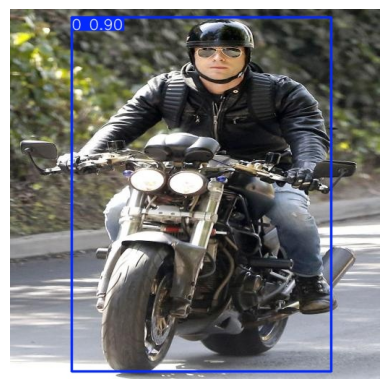

In [ ]:
# Obtenemos el directorio de guardado del objeto de resultados
directorio_guardado = resultados[0].save_dir
ruta_imagen_resultado = os.path.join(directorio_guardado, os.path.basename(ruta_imagen_prueba))

# Cargar y mostrar la imagen
img = Image.open(ruta_imagen_resultado)
plt.imshow(img)
plt.axis('off') # Ocultar los ejes
plt.show()

In [ ]:
import shutil
from google.colab import files

# 1. Especificamos la ruta real donde están tus resultados (basado en tu captura)
folder_path = "/content/runs/detect/YOLOv8_Training"
output_filename = "resultados_entrenamiento" # shutil añade el .zip automáticamente

# 2. Comprimir la carpeta en un archivo ZIP
shutil.make_archive(output_filename, 'zip', folder_path)

# 3. Descargar el archivo ZIP a tu computadora
files.download(output_filename + '.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>